<a href="https://colab.research.google.com/github/Eswa2020/urban-parking-prediction-models/blob/master/notebooks/Melbourne/02_melbourne_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries and loading dataset

In [1]:
#importimg our libraries to use
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
%matplotlib inline

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#let's load the  dataset
dataq=pd.read_csv("/content/drive/MyDrive/melbourne_parking_data.csv",encoding='ISO-8859-1')
dataq.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,02/15/2019 07:45:29 PM,02/15/2019 07:46:52 PM,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True
1,17176,03/25/2019 08:35:40 PM,03/25/2019 08:39:08 PM,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True


In [4]:
dataq.tail(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
1048573,17418,05/15/2019 04:31:54 PM,05/15/2019 04:32:56 PM,1,13397W,430.0,1/4P M-F 16:00-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,False
1048574,17418,05/25/2019 06:10:25 PM,05/25/2019 06:18:14 PM,8,13397W,362.0,1P SAT-SUN 7:30-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,True


The dataset contains parking sensor records from 2019 and appears to be concentrated in Docklands, Melbourne, Australia.

## Exploring our dataset

In [5]:
#We have about 1,048 ,575 rows and 20 columns.
# The dataset contains over 1.04 million valid parking records, which is large enough for robust temporal and operational analysis.
dataq.shape

(1048575, 20)

In [6]:
#We check if we have any null values in our columns
#sign plate has like 20% which is expected behaviour
dataq.isna().sum()

,0
DeviceId,0
ArrivalTime,0
DepartureTime,0
DurationMinutes,0
StreetMarker,0
SignPlateID,286382
Sign,286382
AreaName,1
StreetId,0
StreetName,0


In [7]:
#W have like 407 duplicates...should recheck thsi
dataq.duplicated().sum()

np.int64(407)

In [8]:
#We have several interger columns none seems to be out of place
#we have 2 categorical(and also potential target variables "vehicle present and Inviolation")
dataq.dtypes


,0
DeviceId,int64
ArrivalTime,object
DepartureTime,object
DurationMinutes,int64
StreetMarker,object
SignPlateID,float64
Sign,object
AreaName,object
StreetId,int64
StreetName,object


In [9]:
#WE have 8 columns that are intergers
descriptive_stats = dataq.describe()
print(descriptive_stats)

           DeviceId  DurationMinutes    SignPlateID      StreetId  \
count  1.048575e+06     1.048575e+06  762193.000000  1.048575e+06   
mean   1.731886e+04     4.799476e+01     285.859107  5.186585e+02   
std    2.998304e+02     9.260124e+01     158.747030  3.813933e+02   
min    1.003600e+04     0.000000e+00       3.000000  5.000000e+00   
25%    1.725800e+04     3.000000e+00     196.000000  1.230000e+02   
50%    1.731300e+04     1.200000e+01     285.000000  5.280000e+02   
75%    1.736800e+04     4.600000e+01     421.000000  7.530000e+02   
max    2.842100e+04     1.440000e+03     715.000000  1.497000e+03   

       BetweenStreet1ID  BetweenStreet2ID  SideOfStreet         BayId  
count      1.048575e+06      1.048575e+06  1.048575e+06  1.048575e+06  
mean       6.465055e+02      6.902358e+02  3.344938e+00  6.236924e+03  
std        4.197601e+02      5.153619e+02  1.092222e+00  2.275697e+02  
min        5.000000e+00      5.000000e+00  1.000000e+00  5.690000e+02  
25%        1.23000

In [10]:
# DurationMinutes has a mean of about 48 minutes, indicating that the average parking event lasts less than one hour.
# The median duration is 12 minutes, which is much lower than the mean and suggests a strongly right-skewed distribution.
# The standard deviation of about 92.6 minutes shows substantial variation in parking duration across events.
# The minimum duration is 0 minutes, which may reflect very short stays, sensor noise, or recording artefacts.
# The 25th percentile is 3 minutes, meaning that a quarter of all parking events are extremely short.
# The 75th percentile is 46 minutes, meaning that most parking events are under one hour in duration.
# The maximum duration is 1,440 minutes, indicating the presence of very long stays or potential outliers in the dataset.

In [13]:
# VehiclePresent frequency shows how often bays are recorded as occupied versus unoccupied in the dataset.
# InViolation frequency shows how often parking events are recorded as violating parking rules.
# These distributions help assess class balance before any classification or operational analysis.

vehicle_status_freq = dataq['VehiclePresent'].value_counts()
in_violation_freq = dataq['InViolation'].value_counts()

print("Vehicle Presence Frequency:")
print(vehicle_status_freq)

print("\nIn Violation Frequency:")
print(in_violation_freq)

Vehicle Presence Frequency:
VehiclePresent
True     537207
False    511368
Name: count, dtype: int64

In Violation Frequency:
InViolation
False    993420
True      55155
Name: count, dtype: int64


In [14]:
# VehiclePresent is fairly balanced, with 537,207 True values and 511,368 False values, indicating a near-even split between occupied and unoccupied observations.
# InViolation is strongly skewed toward non-violations, with 993,420 False values versus 55,155 True values, indicating that parking violations are relatively rare events in the dataset.


##Cleaning Data

In [15]:
# Data cleaning prepares the raw parking records for reliable analysis and modeling.
# This step removes duplicates, fixes datetime fields, checks missing values, and standardizes key variables.

In [16]:
# Create a working copy to avoid changing the original dataset.
df = dataq.copy()


In [17]:
# Check dataset shape before cleaning.
print("Initial shape:", df.shape)

Initial shape: (1048575, 20)


In [18]:
# Remove duplicate records to avoid repeated parking events influencing the analysis.
df = df.drop_duplicates()

In [19]:
# Convert datetime columns into proper datetime format for time-based analysis.
df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")

/tmp/ipykernel_5970/2302069356.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
/tmp/ipykernel_5970/2302069356.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")


In [20]:
# Check missing values in the main variables used for analysis.
missing_summary = df[[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "StreetName", "BayId", "VehiclePresent", "InViolation"
]].isnull().sum()

print("\nMissing values in key columns:")
print(missing_summary)


Missing values in key columns:
ArrivalTime        0
DepartureTime      0
DurationMinutes    0
AreaName           1
StreetName         0
BayId              0
VehiclePresent     0
InViolation        0
dtype: int64


In [21]:
# Drop rows with missing values in essential analytical fields.
df = df.dropna(subset=[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "BayId", "VehiclePresent", "InViolation"
])

In [22]:
# Keep only non-negative durations because negative parking time is not valid.
df = df[df["DurationMinutes"] >= 0]

In [23]:
# Convert boolean status fields into integer form for easier aggregation and modeling.
df["VehiclePresent"] = df["VehiclePresent"].astype(int)
df["InViolation"] = df["InViolation"].astype(int)

In [24]:
# Check dataset shape after cleaning.
print("\nCleaned shape:", df.shape)

# Display data types after cleaning.
print("\nData types after cleaning:")
print(df.dtypes)



Cleaned shape: (1048167, 20)

Data types after cleaning:
DeviceId                     int64
ArrivalTime         datetime64[ns]
DepartureTime       datetime64[ns]
DurationMinutes              int64
StreetMarker                object
SignPlateID                float64
Sign                        object
AreaName                    object
StreetId                     int64
StreetName                  object
BetweenStreet1ID             int64
BetweenStreet1              object
BetweenStreet2ID             int64
BetweenStreet2              object
SideOfStreet                 int64
SideOfStreetCode            object
SideName                    object
BayId                        int64
InViolation                  int64
VehiclePresent               int64
dtype: object


In [25]:
# Preview the cleaned dataset.
df.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,2019-02-15 19:45:29,2019-02-15 19:46:52,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1
1,17176,2019-03-25 20:35:40,2019-03-25 20:39:08,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1


##Feature Enginnering

In [26]:
# Exploratory data analysis is used to understand the distribution, timing, and operational patterns of parking activity.
# This step helps identify skewness, temporal trends, class balance, and area-level variation before modeling.

import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Create core temporal features for exploratory analysis.
df["date"] = df["ArrivalTime"].dt.date
df["month"] = df["ArrivalTime"].dt.month
df["day_of_week"] = df["ArrivalTime"].dt.day_name()
df["arrival_hour"] = df["ArrivalTime"].dt.hour


In [28]:
# Create a weekday/weekend variable for clearer operational comparison.
df["day_type"] = np.where(df["ArrivalTime"].dt.dayofweek >= 5, "Weekend", "Weekday")

In [29]:
# Create a season variable using Australian seasonal grouping.
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df["season"] = df["month"].apply(get_season)

#Forecasting Layer

**Forecasting Objective**

This notebook examines whether short-term parking occupancy in Docklands can be forecast more effectively using temporal structure than by relying on a simple persistence assumption. Because the dataset is overwhelmingly concentrated in Docklands, the forecasting workflow is defined at the street-hour level rather than as a citywide Melbourne model.

The forecasting target is the street-hour occupancy rate, constructed by aggregating parking events by street and hourly timestamp. This unit of analysis is appropriate because it captures short-run operational variation while reducing the noise of raw event-level observations.

In [30]:
# Forecasting is used to estimate short-term parking dynamics over time using aggregated street-hour operational patterns.

In [31]:
#restricted forecasting analysis to the dominant study area to avoid weak signals from very small peripheral groups.
docklands_df = df[df["AreaName"].str.contains("Docklands", case=False, na=False)].copy()

In [32]:
# Created a full datetime hour variable for time-based aggregation.
docklands_df["arrival_hour_ts"] = docklands_df["ArrivalTime"].dt.floor("H")

/tmp/ipykernel_5970/3235687266.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  docklands_df["arrival_hour_ts"] = docklands_df["ArrivalTime"].dt.floor("H")


In [33]:
# Aggregated parking activity by street and hour.
street_hour = (
    docklands_df.groupby(["StreetName", "arrival_hour_ts"], as_index=False)
    .agg(
        occupancy_rate=("VehiclePresent", "mean"),
        mean_duration=("DurationMinutes", "mean"),
        event_count=("BayId", "count"),
        violation_rate=("InViolation", "mean")
    )
    .sort_values(["StreetName", "arrival_hour_ts"])
)

print(street_hour.shape)
street_hour.head()

(78179, 6)


,StreetName,arrival_hour_ts,occupancy_rate,mean_duration,event_count,violation_rate
0,AQUITANIA WAY,2019-04-11 08:00:00,1.000,20.000000,1,0.0
1,AQUITANIA WAY,2019-08-02 16:00:00,0.000,1.000000,1,0.0
2,AQUITANIA WAY,2019-09-30 17:00:00,1.000,0.000000,1,0.0
3,AURORA LANE,2019-08-13 12:00:00,1.000,3.000000,1,0.0
4,BATMANS HILL DRIVE,2019-01-01 00:00:00,0.625,149.208333,24,0.0


In [34]:
#created Lag features

In [35]:
# Lag features capture short-run temporal dependence in parking activity.
street_hour = street_hour.sort_values(["StreetName", "arrival_hour_ts"]).copy()

street_hour["lag_1_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(1)
street_hour["lag_2_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(2)
street_hour["lag_24_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(24)

street_hour["hour"] = street_hour["arrival_hour_ts"].dt.hour
street_hour["day_of_week"] = street_hour["arrival_hour_ts"].dt.dayofweek
street_hour["month"] = street_hour["arrival_hour_ts"].dt.month

street_hour = street_hour.dropna().copy()

print(street_hour.shape)
street_hour.head()

(77847, 12)


,StreetName,arrival_hour_ts,occupancy_rate,mean_duration,event_count,violation_rate,lag_1_occ,lag_2_occ,lag_24_occ,hour,day_of_week,month
28,BATMANS HILL DRIVE,2019-01-02 02:00:00,1.000000,305.000000,1,0.0,0.500000,0.076923,0.625,2,2,1
29,BATMANS HILL DRIVE,2019-01-02 03:00:00,0.500000,64.000000,2,0.0,1.000000,0.500000,0.375,3,2,1
30,BATMANS HILL DRIVE,2019-01-02 04:00:00,1.000000,26.000000,1,0.0,0.500000,1.000000,0.500,4,2,1
31,BATMANS HILL DRIVE,2019-01-02 05:00:00,0.555556,49.000000,9,0.0,1.000000,0.500000,0.000,5,2,1
32,BATMANS HILL DRIVE,2019-01-02 06:00:00,0.571429,35.714286,7,0.0,0.555556,1.000000,0.500,6,2,1


#Forecasting Model Comparison

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Select features for forecasting occupancy rate.
X = street_hour[["lag_1_occ", "lag_2_occ", "lag_24_occ", "hour", "day_of_week", "month"]]
y = street_hour["occupancy_rate"]

In [37]:
# Use a time-ordered split instead of random shuffling.
split_index = int(len(street_hour) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [38]:
# Naive baseline using previous-hour occupancy.
baseline_pred = X_test["lag_1_occ"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

**Forecasting Model Design**

Two forecasting approaches are compared.
 * The first is a naive baseline that assumes the next observed occupancy rate is equal to the previous hour’s value. This provides a simple persistence benchmark.
 * The second is a Random Forest regression model that uses lagged occupancy and temporal features to capture more complex and potentially nonlinear forecasting structure.

A time-ordered train-test split is used instead of random shuffling so that the evaluation better reflects real forecasting conditions and avoids leakage from future observations into the training data.

In [39]:
# Random Forest forecasting model.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)

Baseline MAE: 0.2822931563203458
Baseline RMSE: 0.40105788299538864
RF MAE: 0.17355933561600279
RF RMSE: 0.24656356492962694


In [40]:
## The Random Forest forecasting model substantially improves on the naive baseline, indicating that lagged occupancy and temporal features contain useful predictive signal for Docklands street-hour parking dynamics.

**Forecasting Results Interpretation**

The forecasting results show that the Random Forest model materially outperforms the naive lag baseline. The baseline produced an MAE of 0.2823 and an RMSE of 0.4011, whereas the Random Forest reduced these to 0.1736 and 0.2466 respectively.

*This indicates that Docklands parking occupancy contains useful short-run structure that is not fully captured by a simple persistence rule.*

In practical terms, the model benefits from combining lagged occupancy with broader temporal features such as hour of day, day of week, and month. This suggests that street-hour parking conditions in Docklands are patterned rather than purely random and can therefore support operational forecasting.

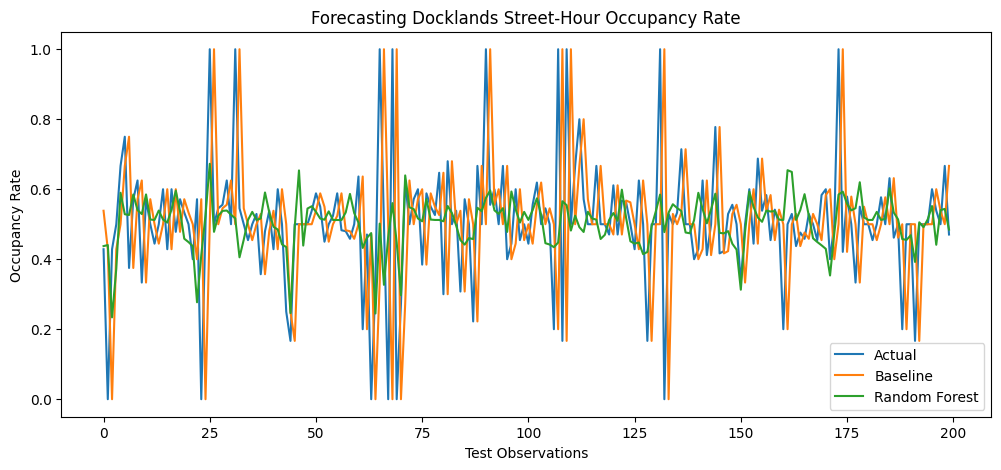

In [41]:
import matplotlib.pyplot as plt

# Compare actual and predicted occupancy rates for a short test window.
plot_df = pd.DataFrame({
    "actual": y_test.values[:200],
    "baseline": baseline_pred.values[:200],
    "rf_pred": rf_pred[:200]
})

plt.figure(figsize=(12, 5))
plt.plot(plot_df["actual"], label="Actual")
plt.plot(plot_df["baseline"], label="Baseline")
plt.plot(plot_df["rf_pred"], label="Random Forest")
plt.title("Forecasting Docklands Street-Hour Occupancy Rate")
plt.xlabel("Test Observations")
plt.ylabel("Occupancy Rate")
plt.legend()
plt.show()

In [42]:
#the baseline tracks the sharp spikes and drops too literally because it just copies the last observed hour, while the Random Forest is smoother and closer to the central occupancy pattern. So the baseline overreacts to volatility, whereas the RF generalizes better.

**Forecast Plot Interpretation**

The comparison plot shows that the naive baseline tends to track sharp swings too literally because it simply carries the previous-hour signal forward.

 By contrast, the Random Forest model produces smoother predictions that align more closely with the central occupancy pattern across the test period.

 This suggests that the feature-based model generalizes better to short-term parking variation.

#Conclusion

This forecasting notebook shows that short-term Docklands street-hour occupancy can be predicted more effectively with a feature-based machine-learning model than with a naive persistence benchmark.

The improvement in both MAE and RMSE indicates that lagged occupancy and temporal variables contain meaningful predictive signal.

These findings support the use of structured street-hour forecasting as a component of urban parking decision support. However, the results should be interpreted as Docklands-specific rather than representative of all Melbourne, given the strong spatial concentration of the dataset.